In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# List the contents of the root directory of your Google Drive
print(os.listdir('/content/drive/MyDrive/KY_9/KY_9_Final_Project/Data/data_train/data_final_train_v2/'))

['data_final_sort_v2.jsonl', 'generate_training_query', 'data_train_v2.pkl', 'cosine_results_v2_model_bkai.csv', 'cosine_results_v2_model_e5.csv', 'data_filtered_cosine_v2_model_e5.pkl', 'bge_rerank_scored.csv']


In [ ]:
import pickle
# LOAD PKL DATA
data_test = '/content/drive/MyDrive/KY_9/KY_9_Final_Project/Data/data_train/data_final_train_v2/data_train_v2.pkl'
with open(data_test, "rb") as f:
     data = pickle.load(f)
print(f"Loaded {len(data)} QA pairs.\n")

Loaded 75355 QA pairs.



In [ ]:
from sentence_transformers import CrossEncoder
import pandas as pd
import torch

# 1. LOAD MODEL (Dùng class CrossEncoder)
# ===============================
model_id = 'BAAI/bge-reranker-v2-m3'
# Load model vào GPU nếu có
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = CrossEncoder(model_id, device=device)

# 2. TÍNH SCORE (Dùng hàm predict)
# ===============================
results_v2 = []

for idx, item in enumerate(data):      # data: list[InputExample]
    query, positive = item.texts

    # --- SỬA ĐỔI QUAN TRỌNG ---
    # Thay vì encode riêng lẻ, ta đưa cả cặp vào hàm predict
    # Hàm predict nhận list các cặp: [[query, passage]]
    score = model.predict([(query, positive)])[0]

    # Chuyển về float python (score có thể là numpy float)
    score = float(score)

    # Lưu kết quả
    results_v2.append({
        "index": idx,
        "query": query,
        "positive": positive,
        "score": score, # Đổi tên 'cosine' thành 'score' cho đúng bản chất
    })

    # === IN RA TỪNG MẪU ===
    print(f"--- Sample {idx+1}/{len(data)} | Score: {score:.4f} ---")

# ===============================
df = pd.DataFrame(results_v2)

# Xem thống kê điểm số để chọn ngưỡng lọc (threshold)
print("\nThống kê điểm số:")
print(df['score'].describe())

In [ ]:
# 3. LƯU KẾT QUẢ (PHẦN BẠN CẦN)
# ===============================
# Định nghĩa đường dẫn file (Dùng đúng thư mục Google Drive của bạn)
folder_path = '/content/drive/MyDrive/KY_9/KY_9_Final_Project/Data/data_train/data_final_train_v2/'
file_name = 'bge_rerank_scored.csv'
output_path = os.path.join(folder_path, file_name)
# Lưu file
# encoding='utf-8-sig': Quan trọng để mở Excel không lỗi font tiếng Việt
# index=False: Không lưu cột số thứ tự thừa
df.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f" Đã lưu thành công file tại: {output_path}")

In [ ]:
import pickle
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer, util
import matplotlib.pyplot as plt

# ===============================
# 0. LOAD
# ===============================
df_cross = pd.read_csv(
    '/content/drive/MyDrive/KY_9/KY_9_Final_Project/Data/data_train/data_final_train_v2/bge_rerank_scored.csv',
    encoding="utf-8"
)

# ===============================
# 1. THRESHOLD + đánh dấu pass/fail
# ===============================
threshold = 0.7   # thử 0.6 / 0.65 / 0.75...
df_cross["pass"] = df_cross["score"] >= threshold

# ===============================
# 2. THỐNG KÊ
# ===============================
total = len(df_cross)
passed = int(df_cross["pass"].sum())
failed = total - passed

mean_score = float(df_cross["score"].mean())
min_score  = float(df_cross["score"].min())
max_score  = float(df_cross["score"].max())

print("========== THỐNG KÊ ==========")
print(f"Tổng số mẫu:         {total}")
print(f"Số mẫu PASS:         {passed}")
print(f"Số mẫu FAIL:         {failed}")
print(f"TỶ LỆ PASS:          {passed/total*100:.2f}%")
print("--------------------------------")
print(f"score TB:           {mean_score:.6f}")
print(f"score thấp nhất:    {min_score:.6f}")
print(f"score cao nhất:     {max_score:.6f}")
print("================================\n")

# ===============================
# 3. In vài cặp nghi ngờ (FAIL) để soi tay
# ===============================
df_cross_fail = df_cross[~df_cross["pass"]].sort_values("score", ascending=True)

print(f"Số cặp bị đánh dấu nghi ngờ (score < {threshold}): {len(df_cross_fail)}\n")

print("===== TOP 10 FAIL THẤP NHẤT =====")
for idx, r in df_cross_fail.head(10).iterrows():
    print("="*80)
    # idx là index gốc trong DataFrame; r là Series của hàng hiện tại
    print(f"Index   : {idx}")
    # đảm bảo r['score'] là float trước khi format
    try:
        print(f"Score   : {float(r['score']):.4f}")
    except Exception:
        print(f"Score   : {r['score']}")
    # Query có thể bị NaN -> guard bằng str(...) và cắt 100 kí tự
    query_preview = str(r.get('query', ''))[:200]
    print(f"Query   : {query_preview}")
    print(f"Positive: {r.get('positive', '')}")


========== THỐNG KÊ ==========
Tổng số mẫu:         74582
Số mẫu PASS:         69344
Số mẫu FAIL:         5238
TỶ LỆ PASS:          92.98%
--------------------------------
score TB:           0.9272
score thấp nhất:    0.0002
score cao nhất:     1.0000

Số cặp bị đánh dấu nghi ngờ (score < 0.7): 5238



In [ ]:
import pickle
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer, util
import matplotlib.pyplot as plt

# ===============================
# 0. LOAD
# ===============================
df_cosine = pd.read_csv(
    '/content/drive/MyDrive/KY_9/KY_9_Final_Project/Data/data_train/data_final_train_v2/cosine_results_v2_model_e5.csv',
    encoding="utf-8"
)

# ===============================
# 1. THRESHOLD + đánh dấu pass/fail
# ===============================
threshold = 0.71   # thử 0.6 / 0.65 / 0.75...
df_cosine["pass"] = df_cosine["cosine"] >= threshold

# ===============================
# 2. THỐNG KÊ
# ===============================
total = len(df_cosine)
passed = int(df_cosine["pass"].sum())
failed = total - passed

mean_cosine = float(df_cosine["cosine"].mean())
min_cosine  = float(df_cosine["cosine"].min())
max_cosine  = float(df_cosine["cosine"].max())

print("========== THỐNG KÊ ==========")
print(f"Tổng số mẫu:         {total}")
print(f"Số mẫu PASS:         {passed}")
print(f"Số mẫu FAIL:         {failed}")
print(f"TỶ LỆ PASS:          {passed/total*100:.2f}%")
print("--------------------------------")
print(f"cosine TB:           {mean_cosine:.4f}")
print(f"cosine thấp nhất:    {min_cosine:.4f}")
print(f"cosine cao nhất:     {max_cosine:.4f}")
print("================================\n")

# ===============================
# 3. In vài cặp nghi ngờ (FAIL) để soi tay
# ===============================
df_cosine_fail = df_cosine[~df_cosine["pass"]].sort_values("cosine", ascending=True)

print(f"Số cặp bị đánh dấu nghi ngờ (cosine < {threshold}): {len(df_cosine_fail)}\n")

print("===== TOP 10 FAIL THẤP NHẤT =====")
for idx, r in df_cosine_fail.head(10).iterrows():
    print("="*80)
    # idx là index gốc trong DataFrame; r là Series của hàng hiện tại
    print(f"Index   : {idx}")
    # đảm bảo r['cosine'] là float trước khi format
    try:
        print(f"cosine   : {float(r['cosine']):.4f}")
    except Exception:
        print(f"cosine   : {r['cosine']}")
    # Query có thể bị NaN -> guard bằng str(...) và cắt 100 kí tự
    query_preview = str(r.get('query', ''))[:200]
    print(f"Query   : {query_preview}")
    print(f"Positive: {r.get('positive', '')}")
df_cosine

========== THỐNG KÊ ==========
Tổng số mẫu:         75355
Số mẫu PASS:         75355
Số mẫu FAIL:         0
TỶ LỆ PASS:          100.00%
--------------------------------
cosine TB:           0.8569
cosine thấp nhất:    0.7181
cosine cao nhất:     0.9568



,index,query,positive,cosine,pass
0,0,query: An Giang đẹp vào mùa nào?,passage: An Giang mùa nào đẹp. ở An Giang: Từ ...,0.904786,True
1,1,query: Thời gian nào là mùa nắng khô ráo ở An ...,passage: An Giang mùa nào đẹp. ở An Giang: Từ ...,0.896993,True
2,2,query: Khi nào là thời điểm tốt để ngắm thảm b...,passage: An Giang mùa nào đẹp. ở An Giang: Từ ...,0.859969,True
3,3,query: Bạn có thể chiêm ngưỡng mùa gặt ở Tà Pạ...,passage: An Giang mùa nào đẹp. ở An Giang: Từ ...,0.858550,True
4,4,query: Hai lễ hội lớn ở An Giang diễn ra vào t...,passage: An Giang mùa nào đẹp. ở An Giang: Từ ...,0.862062,True
...,...,...,...,...,...
75350,75350,query: Quán PỜ CAFÉ có cơ sở ở đâu?,passage: Quán có cơ sở ở phố đi bộ Nguyễn Huệ ...,0.838476,True
75351,75351,query: Không gian quán cà phê mới ở TP HCM man...,passage: Quán có cơ sở ở phố đi bộ Nguyễn Huệ ...,0.863266,True
75352,75352,query: PỜ CAFÉ chuyên về món uống nào nổi tiến...,passage: Quán có cơ sở ở phố đi bộ Nguyễn Huệ ...,0.871864,True
75353,75353,query: Menu tại PỜ CAFÉ có những món uống nào ...,passage: Quán có cơ sở ở phố đi bộ Nguyễn Huệ ...,0.883722,True


In [ ]:

# ========= LOAD =========
df_cosine = pd.read_csv(
    "/content/drive/MyDrive/KY_9/KY_9_Final_Project/Data/data_train/data_final_train_v2/cosine_results_v2_model_e5.csv",
    encoding="utf-8"
)

df_cross = pd.read_csv(
    "/content/drive/MyDrive/KY_9/KY_9_Final_Project/Data/data_train/data_final_train_v2/bge_rerank_scored.csv",
    encoding="utf-8"
)

# ====== MERGE theo cột chung (ví dụ: id) ======
df = df_cosine.merge(df_cross[["index", "score"]], on="index", how="left")

# ====== THRESHOLD ======
df["pass_cosine"] = df["cosine"] >= 0.75
df["pass_rerank"] = df["score"] >= 0.75


In [ ]:
df

,index,query,positive,cosine,score,pass_cosine,pass_rerank
0,0,query: An Giang đẹp vào mùa nào?,passage: An Giang mùa nào đẹp. ở An Giang: Từ ...,0.904786,0.995538,True,True
1,1,query: Thời gian nào là mùa nắng khô ráo ở An ...,passage: An Giang mùa nào đẹp. ở An Giang: Từ ...,0.896993,0.995380,True,True
2,2,query: Khi nào là thời điểm tốt để ngắm thảm b...,passage: An Giang mùa nào đẹp. ở An Giang: Từ ...,0.859969,0.986874,True,True
3,3,query: Bạn có thể chiêm ngưỡng mùa gặt ở Tà Pạ...,passage: An Giang mùa nào đẹp. ở An Giang: Từ ...,0.858550,0.993392,True,True
4,4,query: Hai lễ hội lớn ở An Giang diễn ra vào t...,passage: An Giang mùa nào đẹp. ở An Giang: Từ ...,0.862062,0.993213,True,True
...,...,...,...,...,...,...,...
75350,75350,query: Quán PỜ CAFÉ có cơ sở ở đâu?,passage: Quán có cơ sở ở phố đi bộ Nguyễn Huệ ...,0.838476,NaN,True,False
75351,75351,query: Không gian quán cà phê mới ở TP HCM man...,passage: Quán có cơ sở ở phố đi bộ Nguyễn Huệ ...,0.863266,NaN,True,False
75352,75352,query: PỜ CAFÉ chuyên về món uống nào nổi tiến...,passage: Quán có cơ sở ở phố đi bộ Nguyễn Huệ ...,0.871864,NaN,True,False
75353,75353,query: Menu tại PỜ CAFÉ có những món uống nào ...,passage: Quán có cơ sở ở phố đi bộ Nguyễn Huệ ...,0.883722,NaN,True,False


In [ ]:
for th in [0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.9, 0.95]:
    fail_rate = (df_cross["score"] < th).mean() * 100
    print(f"threshold={th:.2f}  ->  fail={fail_rate:.2f}%")

threshold=0.40  ->  fail=2.73%
threshold=0.45  ->  fail=3.20%
threshold=0.50  ->  fail=3.75%
threshold=0.55  ->  fail=4.37%
threshold=0.60  ->  fail=5.08%
threshold=0.65  ->  fail=5.94%
threshold=0.70  ->  fail=7.02%
threshold=0.75  ->  fail=8.35%
threshold=0.80  ->  fail=10.13%
threshold=0.90  ->  fail=16.95%
threshold=0.95  ->  fail=26.22%


In [ ]:
for th in [0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.9, 0.95]:
    fail_rate = (df_cosine["cosine"] < th).mean() * 100
    print(f"threshold={th:.2f}  ->  fail={fail_rate:.2f}%")

threshold=0.40  ->  fail=0.00%
threshold=0.45  ->  fail=0.00%
threshold=0.50  ->  fail=0.00%
threshold=0.55  ->  fail=0.00%
threshold=0.60  ->  fail=0.00%
threshold=0.65  ->  fail=0.00%
threshold=0.70  ->  fail=0.00%
threshold=0.75  ->  fail=0.03%
threshold=0.80  ->  fail=3.50%
threshold=0.90  ->  fail=94.31%
threshold=0.95  ->  fail=100.00%


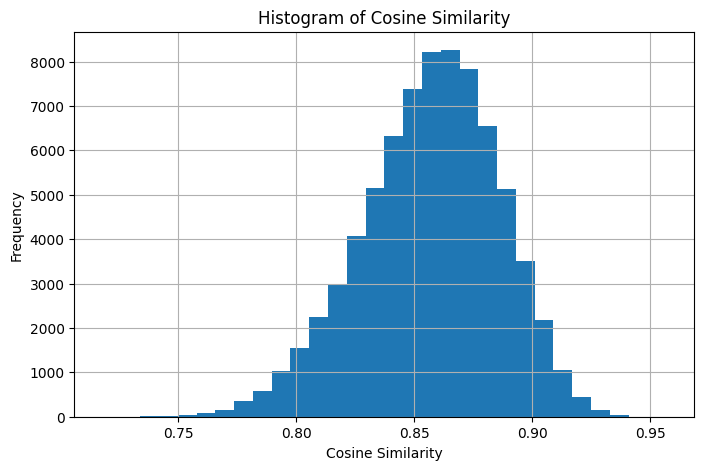

In [ ]:
6. #HISTOGRAM
# ===============================
plt.figure(figsize=(8,5))
plt.hist(df["cosine"], bins=30)
plt.title("Histogram of Cosine Similarity")
plt.xlabel("Cosine Similarity")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


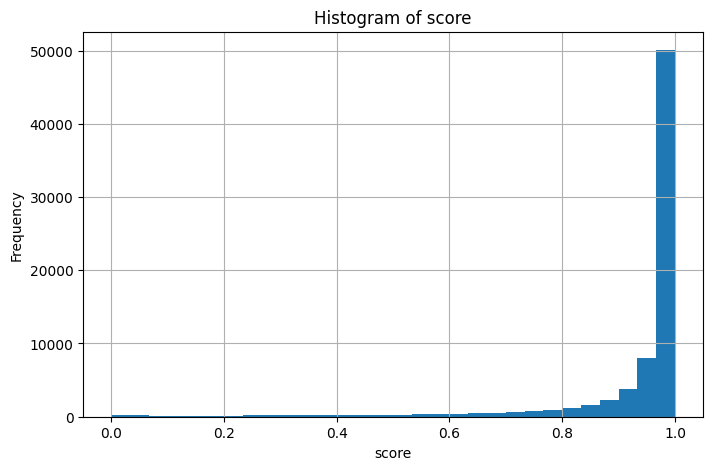

In [ ]:
6. #HISTOGRAM
# ===============================
plt.figure(figsize=(8,5))
plt.hist(df["score"], bins=30)
plt.title("Histogram of score")
plt.xlabel("score")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


In [ ]:
import pandas as pd
import numpy as np

# ========= LOAD =========
df_cosine = pd.read_csv(
    "/content/drive/MyDrive/KY_9/KY_9_Final_Project/Data/data_train/data_final_train_v2/cosine_results_v2_model_e5.csv",
    encoding="utf-8"
)

df_cross = pd.read_csv(
    "/content/drive/MyDrive/KY_9/KY_9_Final_Project/Data/data_train/data_final_train_v2/bge_rerank_scored.csv",
    encoding="utf-8"
)

# ====== MERGE ======
df = df_cosine.merge(df_cross[["index", "score"]], on="index", how="left")

# ép kiểu
df["cosine"] = pd.to_numeric(df["cosine"], errors="coerce")
df["score"]  = pd.to_numeric(df["score"], errors="coerce")

# ===============================
# 1. THRESHOLD + ĐÁNH DẤU PASS
# ===============================
threshold = 0.8

df["pass_cosine"] = df["cosine"] >= threshold
df["pass_rerank"] = df["score"]  >= threshold

# Require BOTH cosine & rerank đạt threshold
df["pass_both"] = df["pass_cosine"] & df["pass_rerank"]

# ===============================
# 2. THỐNG KÊ
# ===============================
total = len(df)
passed = int(df["pass_both"].sum())
failed = total - passed

mean_score = float(df["cosine"].mean())
min_score  = float(df["cosine"].min())
max_score  = float(df["cosine"].max())

print("========== THỐNG KÊ ==========")
print(f"Tổng số mẫu:         {total}")
print(f"Số mẫu PASS:         {passed}")
print(f"Số mẫu FAIL:         {failed}")
print(f"TỶ LỆ PASS:          {passed/total*100:.2f}%")
print("--------------------------------")
print(f"Cosine TB:           {mean_score:.4f}")
print(f"Cosine thấp nhất:    {min_score:.4f}")
print(f"Cosine cao nhất:     {max_score:.4f}")
print("================================\n")

# ===============================
# 3. Soi các cặp FAIL
# ===============================
df_fail = df[~df["pass_both"]].sort_values("cosine", ascending=True)

print(f"Số cặp bị đánh dấu FAIL (cosine < {threshold} hoặc rerank < {threshold}): {len(df_fail)}\n")

print("===== TOP 10 FAIL THẤP NHẤT =====")
for _, r in df_fail.head(10).iterrows():
    print("="*80)
    print(f"Index   : {r['index']}")
    print(f"Cosine  : {r['cosine']:.4f}")
    print(f"Rerank  : {r['score']:.4f}")
    print(f"Query   : {r['query'][:200]}")
    print(f"Positive: {r['positive'][:200]}")


# ===============================
# 4. LỌC CẶP PASS
# ===============================
df_pass = df[df["pass_both"] == True].copy()

print(f"\nSố lượng cặp PASS_BOTH sẽ được lưu: {len(df_pass)}")


# ===============================
# 5. CHUYỂN NGƯỢC VỀ LIST InputExample (E5 style)
# ===============================
import pickle
from sentence_transformers import InputExample

filtered_data = []

for _, row in df_pass.iterrows():
    query_text = str(row["query"])
    pos_text   = str(row["positive"])
    filtered_data.append(InputExample(texts=[query_text, pos_text]))


# ===============================
# 6. LƯU FILE PKL
# ===============================
output_pkl = "/content/drive/MyDrive/KY_9/KY_9_Final_Project/Data/data_train/data_final_train_v2/data_filtered_v2.pkl"

with open(output_pkl, "wb") as f:
    pickle.dump(filtered_data, f)

print(" DONE! Đã lưu file PKL dạng E5 prefix.")
print(" File output:", output_pkl)


========== THỐNG KÊ ==========
Tổng số mẫu:         75355
Số mẫu PASS:         65539
Số mẫu FAIL:         9816
TỶ LỆ PASS:          86.97%
--------------------------------
Cosine TB:           0.8569
Cosine thấp nhất:    0.7181
Cosine cao nhất:     0.9568

Số cặp bị đánh dấu FAIL (cosine < 0.8 hoặc rerank < 0.8): 9816

===== TOP 10 FAIL THẤP NHẤT =====
Index   : 19074
Cosine  : 0.7181
Rerank  : 0.0013
Query   : query: Mục đích của bài viết là gì?
Positive: passage: Nghệ An mặc dù nằm cách Đà Nẵng khá xe, khoảng hơn 600 km nhưng nhu cầu di chuyển từ Nghệ An đến Đà Nẵng bằng xe khách vẫn rất nhiều. Ngoài các loại xe khách thông thường, trong những năm gần
Index   : 14256
Cosine  : 0.7298
Rerank  : 0.4733
Query   : query: Thời gian chương trình acoustic diễn ra vào lúc nào?
Positive: passage: Đạp xe ngắm cảnh.. Thử sức với các trò chơi mạo hiểm: zipline, luyện giữ thăng bằng zigzang, cầu gỗ treo…. Chương trình acoustic từ 7:00 – 9:00 tối (Thứ 6/Thứ 7/Chủ nhật).. Đốt lửa trại, xem 
Index  

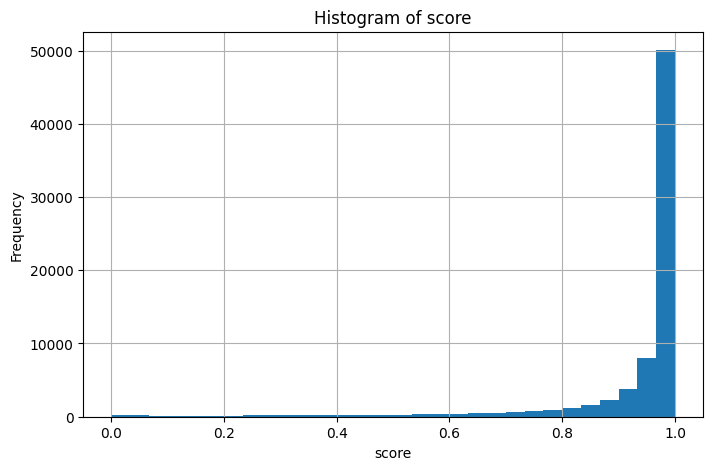

In [ ]:
import matplotlib.pyplot as plt
6. #HISTOGRAM
# ===============================
plt.figure(figsize=(8,5))
plt.hist(df["score"], bins=30)
plt.title("Histogram of score")
plt.xlabel("score")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()